# Finite-Difference Laplacian in One Dimension

The one-dimensional Laplacian is

$$
\nabla^2=\frac{\mathrm d^2}{\mathrm dx^2}.
$$

This notebook constructs its second-order finite-difference representation on a CartesianGrid1D, restricts it to the active interior degrees of freedom, and validates the sparse operator against an analytical derivative.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from physkit.core.grids import ActiveSet1D, CartesianGrid1D
from physkit.numerics.differentiation.laplacian import FiniteDifferenceLaplacian1D

## 1. Finite-Difference Approximation

For uniformly spaced coordinates $x_i=x_{\min}+i\Delta x$, the centered approximation is

$$
\frac{\mathrm d^2u}{\mathrm dx^2}\bigg|_{x_i}
=
\frac{u_{i-1}-2u_i+u_{i+1}}{\Delta x^2}
+\mathcal O(\Delta x^2).
$$

The three-point stencil is

$$
\frac{1}{\Delta x^2}
\begin{bmatrix}1&-2&1\end{bmatrix}.
$$

## 2. Grid and Active State Space

Consider $x\in[0,1]$ with homogeneous Dirichlet boundary conditions,

$$
u(0)=u(1)=0.
$$

The active interior indices are

$$
\mathcal I_A=\{1,2,\ldots,N_x-2\},
\qquad N_A=N_x-2.
$$

In [2]:
grid = CartesianGrid1D(
    x_lower=0.0,
    x_upper=1.0,
    Nx=11,
    endpoint=True,
)

interior_indices = np.arange(
    1,
    grid.x.N - 1,
    dtype=np.int64,
)

grid_interior_dofs = ActiveSet1D(
    grid=grid,
    indices=interior_indices,
)

print(grid)
print(f"Grid spacing: {grid.x.delta}")
print(f"Active indices: {grid_interior_dofs.indices}")
print(f"Active-state size: {grid_interior_dofs.size}")

CartesianGrid1D(x_min=0.0, x_max=1.0, Nx=11, endpoint=True)
Grid spacing: 0.1
Active indices: [1 2 3 4 5 6 7 8 9]
Active-state size: 9


## 3. Sparse Laplacian Operator

On the interior state, the discrete Laplacian is

$$
D_{xx}^{(A)}=\frac{1}{\Delta x^2}
\begin{bmatrix}
-2&1&0&\cdots&0\\
1&-2&1&\ddots&\vdots\\
0&1&-2&\ddots&0\\
\vdots&\ddots&\ddots&\ddots&1\\
0&\cdots&0&1&-2
\end{bmatrix}.
$$

It defines $D_{xx}^{(A)}:\mathbb R^{N_A}\rightarrow\mathbb R^{N_A}$. Sparse storage is canonical because only three diagonals are populated.

In [3]:
laplacian = FiniteDifferenceLaplacian1D(
    grid=grid,
    active_set=grid_interior_dofs,
)

print(f"Matrix shape: {laplacian.matrix.shape}")
print(f"Storage format: {laplacian.matrix.format}")
print(f"Stored nonzero entries: {laplacian.matrix.nnz}")

Matrix shape: (9, 9)
Storage format: csr
Stored nonzero entries: 25


## 4. Dense Inspection and Sparsity

For a small example, convert the sparse matrix temporarily to a dense array for inspection. The dense array is not stored as a second operator representation.

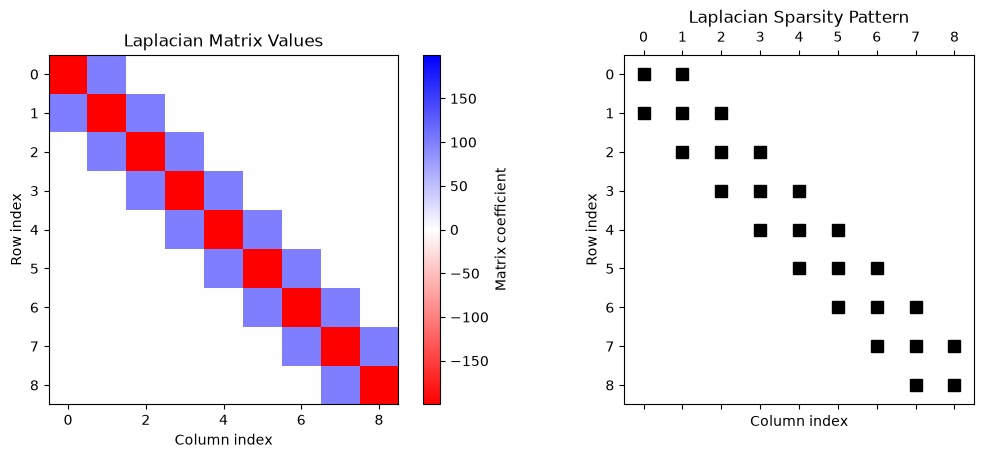

In [13]:
from matplotlib.colors import (
    LinearSegmentedColormap,
    TwoSlopeNorm,
)


dense_laplacian = (
    laplacian.matrix.toarray()
)

maximum_magnitude = np.max(
    np.abs(dense_laplacian)
)

normalization = TwoSlopeNorm(
    vmin=-maximum_magnitude,
    vcenter=0.0,
    vmax=maximum_magnitude,
)

red_white_blue = (
    LinearSegmentedColormap.from_list(
        "red_white_blue",
        [
            "red",
            "white",
            "blue",
        ],
    )
)

fig, axes = plt.subplots(
    ncols=2,
    figsize=(11, 4.5),
)

image = axes[0].imshow(
    dense_laplacian,
    cmap=red_white_blue,
    norm=normalization,
    interpolation="nearest",
)

axes[0].set_xlabel("Column index")
axes[0].set_ylabel("Row index")
axes[0].set_title("Laplacian Matrix Values")

colorbar = fig.colorbar(
    image,
    ax=axes[0],
)

colorbar.set_label(
    "Matrix coefficient"
)

axes[1].spy(
    laplacian.matrix,
    markersize=8,
    color="black",
)

axes[1].set_xlabel("Column index")
axes[1].set_ylabel("Row index")
axes[1].set_title("Laplacian Sparsity Pattern")

fig.tight_layout()

plt.show()

## 5. Apply the Operator

Use

$$
u(x)=\sin(\pi x),
$$

which satisfies the boundary conditions and has exact second derivative

$$
u''(x)=-\pi^2\sin(\pi x).
$$

The complete field is sampled on the grid, restricted to the active indices, and then acted on by the sparse Laplacian.

In [5]:
u = np.sin(np.pi * grid.x.values)
u_interior = u[grid_interior_dofs.indices]

numerical_second_derivative = (
    laplacian.matrix @ u_interior
)

exact_second_derivative = (
    -np.pi**2 * u_interior
)

print("Numerical second derivative:")
print(np.array2string(
    numerical_second_derivative,
    precision=5,
    suppress_small=True,
    separator=", ",
))

print("\nExact second derivative:")
print(np.array2string(
    exact_second_derivative,
    precision=5,
    suppress_small=True,
    separator=", ",
))

Numerical second derivative:
[-3.02487, -5.75365, -7.91922, -9.3096 , -9.7887 , -9.3096 , -7.91922,
 -5.75365, -3.02487]

Exact second derivative:
[-3.04988, -5.80121, -7.98468, -9.38655, -9.8696 , -9.38655, -7.98468,
 -5.80121, -3.04988]


## 6. Numerical Error

The pointwise error and maximum norm are

$$
e_i=u''_{i,\mathrm{numerical}}-u''_{i,\mathrm{exact}},
$$

$$
\lVert\mathbf e\rVert_\infty=\max_i|e_i|.
$$

Maximum absolute error: 8.090766e-02


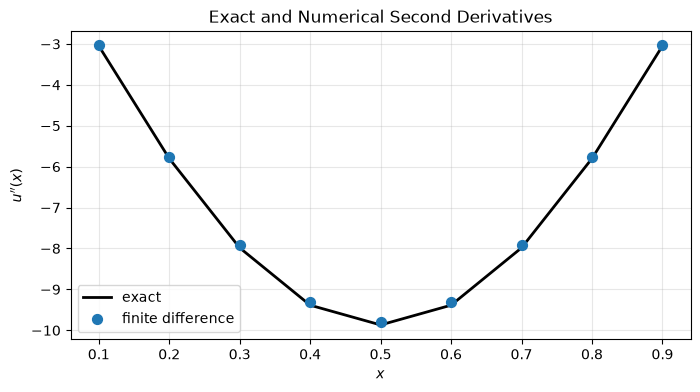

In [6]:
error = (
    numerical_second_derivative
    - exact_second_derivative
)

maximum_error = np.max(np.abs(error))

print(
    f"Maximum absolute error: "
    f"{maximum_error:.6e}"
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    grid_interior_dofs.coordinates,
    exact_second_derivative,
    color="black",
    linewidth=2.0,
    label="exact",
)
ax.scatter(
    grid_interior_dofs.coordinates,
    numerical_second_derivative,
    color="tab:blue",
    s=50,
    label="finite difference",
    zorder=3,
)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$u''(x)$")
ax.set_title("Exact and Numerical Second Derivatives")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## 7. Convergence Study

For a second-order centered difference,

$$
E(\Delta x)=\mathcal O(\Delta x^2),
$$

where $E=\lVert\mathbf e\rVert_\infty$. The observed order between successive grids is

$$
p=\frac{\log(E_h/E_{h/2})}{\log(h/(h/2))}.
$$

In [7]:
def calculate_laplacian_error(
    Nx: int,
) -> tuple[float, float]:
    grid = CartesianGrid1D(
        x_lower=0.0,
        x_upper=1.0,
        Nx=Nx,
        endpoint=True,
    )

    active_set = ActiveSet1D(
        grid=grid,
        indices=np.arange(
            1,
            grid.x.N - 1,
            dtype=np.int64,
        ),
    )

    laplacian = FiniteDifferenceLaplacian1D(
        grid=grid,
        active_set=active_set,
    )

    u = np.sin(np.pi * grid.x.values)
    u_active = u[active_set.indices]
    numerical = laplacian.matrix @ u_active
    exact = -np.pi**2 * u_active
    error = np.max(np.abs(numerical - exact))

    return grid.x.delta, float(error)

In [8]:
N_values = np.array(
    [11, 21, 41, 81, 161],
    dtype=np.int64,
)

results = [
    calculate_laplacian_error(int(Nx))
    for Nx in N_values
]

deltas = np.array(
    [result[0] for result in results],
    dtype=np.float64,
)

errors = np.array(
    [result[1] for result in results],
    dtype=np.float64,
)

observed_orders = (
    np.log(errors[:-1] / errors[1:])
    / np.log(deltas[:-1] / deltas[1:])
)

print(" Nx       delta          error       order")
print("---------------------------------------------")

for index, Nx in enumerate(N_values):
    order = "   ---" if index == 0 else f"{observed_orders[index - 1]:7.4f}"
    print(
        f"{Nx:3d}  "
        f"{deltas[index]:12.6e}  "
        f"{errors[index]:12.6e}  "
        f"{order}"
    )

 Nx       delta          error       order
---------------------------------------------
 11  1.000000e-01  8.090766e-02     ---
 21  5.000000e-02  2.027688e-02   1.9964
 41  2.500000e-02  5.072347e-03   1.9991
 81  1.250000e-02  1.268282e-03   1.9998
161  6.250000e-03  3.170828e-04   1.9999


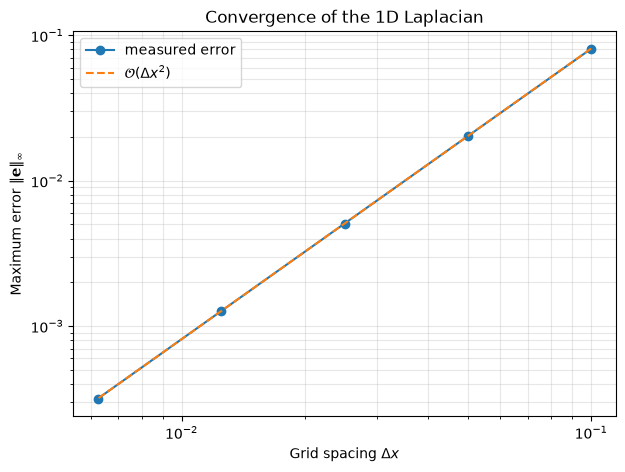

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.loglog(
    deltas,
    errors,
    marker="o",
    label="measured error",
)

reference_error = (
    errors[-1]
    * (deltas / deltas[-1])**2
)

ax.loglog(
    deltas,
    reference_error,
    linestyle="--",
    label=r"$\mathcal{O}(\Delta x^2)$",
)

ax.set_xlabel(r"Grid spacing $\Delta x$")
ax.set_ylabel(r"Maximum error $\|\mathbf{e}\|_\infty$")
ax.set_title("Convergence of the 1D Laplacian")
ax.legend()
ax.grid(which="both", alpha=0.3)
plt.show()

## 8. Dense and Sparse Storage

For $N_A$ active degrees of freedom, dense storage allocates

$$
N_{\mathrm{dense}}=N_A^2
$$

entries, while a tridiagonal sparse matrix stores

$$
N_{\mathrm{sparse}}=3N_A-2
$$

nonzero entries. Dense storage grows quadratically; sparse storage grows linearly.

In [10]:
active_sizes = np.array(
    [10, 100, 1_000, 10_000],
    dtype=np.int64,
)

dense_entries = active_sizes**2
sparse_entries = 3 * active_sizes - 2

print(" N_active    dense entries    sparse entries")
print("---------------------------------------------")

for N_active, dense, sparse in zip(
    active_sizes,
    dense_entries,
    sparse_entries,
):
    print(
        f"{N_active:9d}  "
        f"{dense:15d}  "
        f"{sparse:16d}"
    )

 N_active    dense entries    sparse entries
---------------------------------------------
       10              100                28
      100            10000               298
     1000          1000000              2998
    10000        100000000             29998


## 9. Summary

The grid defines the coordinate representation, the active set defines the numerical state space, and the finite-difference rule defines a sparse linear operator:

$$
\text{grid}
+
\text{active state}
+
\text{finite-difference rule}
\longrightarrow
\text{sparse discrete Laplacian}.
$$

For the centered three-point stencil,

$$
\lVert\mathbf e\rVert_\infty
=
\mathcal O(\Delta x^2).
$$